In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    top_k_accuracy_score
)

from tqdm import tqdm

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random Seed Set:", SEED)

Random Seed Set: 42


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/ActionRecognitionProject"

os.makedirs(PROJECT_PATH, exist_ok=True)

print(PROJECT_PATH)

/content/drive/MyDrive/ActionRecognitionProject


In [ ]:
%cd /content/drive/MyDrive/ActionRecognitionProject

/content/drive/MyDrive/ActionRecognitionProject


In [ ]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

--2026-07-21 17:58:41--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘UCF101.rar’

UCF101.rar          100%[===================>]   6.46G  25.5MB/s    in 4m 22s  

2026-07-21 18:03:04 (25.2 MB/s) - ‘UCF101.rar’ saved [6932971618/6932971618]



In [ ]:
!apt-get -qq install unrar

In [ ]:
!unrar x -o+ UCF101.rar

Streaming output truncated to the last 5000 lines.
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi             62%  OK 
Extracting  UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi             62%  OK 
Extracting  UCF-101/PlayingGu

In [ ]:
!ls

UCF-101  UCF101.rar


In [ ]:
!wget --no-check-certificate https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip

--2026-07-21 18:12:03--  https://www.crcv.ucf.edu/data/UCF101/UCF101TrainTestSplits-RecognitionTask.zip
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 113943 (111K) [application/zip]
Saving to: ‘UCF101TrainTestSplits-RecognitionTask.zip’

UCF101TrainTestSpli 100%[===================>] 111.27K   511KB/s    in 0.2s    

2026-07-21 18:12:04 (511 KB/s) - ‘UCF101TrainTestSplits-RecognitionTask.zip’ saved [113943/113943]



In [ ]:
!unzip -o UCF101TrainTestSplits-RecognitionTask.zip

Archive:  UCF101TrainTestSplits-RecognitionTask.zip
   creating: ucfTrainTestlist/
  inflating: ucfTrainTestlist/classInd.txt  
  inflating: ucfTrainTestlist/testlist01.txt  
  inflating: ucfTrainTestlist/testlist02.txt  
  inflating: ucfTrainTestlist/testlist03.txt  
  inflating: ucfTrainTestlist/trainlist01.txt  
  inflating: ucfTrainTestlist/trainlist02.txt  
  inflating: ucfTrainTestlist/trainlist03.txt  


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/ActionRecognitionProject/UCF-101"
SPLIT_PATH = "/content/drive/MyDrive/ActionRecognitionProject/ucfTrainTestlist"

print("Dataset Exists :", os.path.exists(DATASET_PATH))
print("Split Files Exist :", os.path.exists(SPLIT_PATH))

classes = sorted(os.listdir(DATASET_PATH))

print("Number of Classes :", len(classes))
print("First 10 Classes:")
print(classes[:10])

Dataset Exists : True
Split Files Exist : True
Number of Classes : 101
First 10 Classes:
['ApplyEyeMakeup', 'ApplyLipstick', 'Archery', 'BabyCrawling', 'BalanceBeam', 'BandMarching', 'BaseballPitch', 'Basketball', 'BasketballDunk', 'BenchPress']


In [ ]:
TRAIN_LIST = os.path.join(SPLIT_PATH, "trainlist01.txt")

with open(TRAIN_LIST, "r") as file:
    train_videos = file.readlines()

print("Total Training Videos:", len(train_videos))

print("\nFirst 5 Training Samples:\n")

for sample in train_videos[:5]:
    print(sample.strip())

Total Training Videos: 9537

First 5 Training Samples:

ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c01.avi 1
ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c02.avi 1
ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c03.avi 1
ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c04.avi 1
ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c05.avi 1


In [ ]:
# Video preprocessing parameters

IMAGE_SIZE = 112      # Frame size (112x112)
NUM_FRAMES = 16        # Number of frames sampled from each video

In [ ]:
def load_video(video_path, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE):
    cap = cv2.VideoCapture(video_path)

    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames < num_frames:
        frame_indices = np.linspace(0, max(total_frames - 1, 0), num_frames, dtype=int)
    else:
        frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    current_frame = 0
    selected_index = 0

    while cap.isOpened():

        ret, frame = cap.read()

        if not ret:
            break

        if selected_index < len(frame_indices) and current_frame == frame_indices[selected_index]:

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frame = cv2.resize(frame, (image_size, image_size))

            frame = frame.astype(np.float32) / 255.0

            frames.append(frame)

            selected_index += 1

        current_frame += 1

    cap.release()

    while len(frames) < num_frames:
        frames.append(np.zeros((image_size, image_size, 3), dtype=np.float32))

    frames = np.array(frames)

    return frames

In [ ]:
# Get the first training video
sample_video = train_videos[0].strip().split()[0]

video_path = os.path.join(DATASET_PATH, sample_video)

print("Sample Video:", video_path)

frames = load_video(video_path)

print("Frames Shape:", frames.shape)

Sample Video: /content/drive/MyDrive/ActionRecognitionProject/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g08_c01.avi
Frames Shape: (16, 112, 112, 3)


In [ ]:
class UCF101Dataset(Dataset):

    def __init__(self, video_list, dataset_path):
        self.video_list = video_list
        self.dataset_path = dataset_path

    def __len__(self):
        return len(self.video_list)

    def __getitem__(self, index):

        sample = self.video_list[index].strip().split()

        video_name = sample[0]

        if len(sample) == 2:
            label = int(sample[1]) - 1
        else:
            class_name = video_name.split('/')[0]
            label = classes.index(class_name)

        video_path = os.path.join(self.dataset_path, video_name)

        frames = load_video(video_path)

        frames = torch.tensor(frames, dtype=torch.float32)

        frames = frames.permute(3, 0, 1, 2)

        return frames, label

In [ ]:
train_dataset = UCF101Dataset(
    video_list=train_videos,
    dataset_path=DATASET_PATH
)

print("Number of Training Videos:", len(train_dataset))

Number of Training Videos: 9537


In [ ]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Training DataLoader Created Successfully")

Training DataLoader Created Successfully


In [ ]:
TEST_LIST = os.path.join(SPLIT_PATH, "testlist01.txt")

with open(TEST_LIST, "r") as file:
    test_videos = file.readlines()

print("Total Test Videos:", len(test_videos))

print("\nFirst 5 Test Samples:\n")

for sample in test_videos[:5]:
    print(sample.strip())

Total Test Videos: 3783

First 5 Test Samples:

ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi
ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c02.avi
ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c03.avi
ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c04.avi
ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c05.avi


In [ ]:
test_dataset = UCF101Dataset(
    video_list=test_videos,
    dataset_path=DATASET_PATH
)

print("Number of Test Videos:", len(test_dataset))

Number of Test Videos: 3783


In [ ]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test DataLoader Created Successfully")

Test DataLoader Created Successfully


In [ ]:
class ActionRecognition3DCNN(nn.Module):

    def __init__(self, num_classes=101):
        super(ActionRecognition3DCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv3d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2)),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 2, 2))
        )

        self.pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x

In [ ]:
NUM_CLASSES = 101

model = ActionRecognition3DCNN(num_classes=NUM_CLASSES)

model = model.to(device)

print(model)

ActionRecognition3DCNN(
  (features): Sequential(
    (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
    (6): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  (classifier): Linear(in_features=128, out_features=101, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

print("Loss Function:", criterion)

Loss Function: CrossEntropyLoss()


In [ ]:
LEARNING_RATE = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [ ]:
EPOCHS = 5

CHECKPOINT_PATH = "action_recognition_3dcnn.pth"

print("Epochs:", EPOCHS)
print("Checkpoint Path:", CHECKPOINT_PATH)

Epochs: 5
Checkpoint Path: action_recognition_3dcnn.pth


In [ ]:
def train_model(model, train_loader, criterion, optimizer, epochs):

    model.train()

    for epoch in range(epochs):

        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for videos, labels in progress_bar:

            videos = videos.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(videos)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            progress_bar.set_postfix(
                Loss=running_loss / (progress_bar.n + 1),
                Accuracy=100 * correct / total
            )

        epoch_loss = running_loss / len(train_loader)
        epoch_accuracy = 100 * correct / total

        print(f"\nEpoch [{epoch+1}/{epochs}]")
        print(f"Loss: {epoch_loss:.4f}")
        print(f"Accuracy: {epoch_accuracy:.2f}%")

        torch.save(model.state_dict(), CHECKPOINT_PATH)

    print("\nTraining Completed Successfully.")

In [ ]:
train_model(model, train_loader, criterion, optimizer, EPOCHS)

Epoch 1/5: 100%|██████████| 1193/1193 [11:19<00:00,  1.76it/s, Accuracy=2.42, Loss=4.46]



Epoch [1/5]
Loss: 4.4586
Accuracy: 2.42%


Epoch 2/5: 100%|██████████| 1193/1193 [08:46<00:00,  2.27it/s, Accuracy=8.35, Loss=3.91]



Epoch [2/5]
Loss: 3.9067
Accuracy: 8.35%


Epoch 3/5: 100%|██████████| 1193/1193 [08:38<00:00,  2.30it/s, Accuracy=14.9, Loss=3.51]



Epoch [3/5]
Loss: 3.5130
Accuracy: 14.89%


Epoch 4/5: 100%|██████████| 1193/1193 [08:40<00:00,  2.29it/s, Accuracy=23.5, Loss=3.09]



Epoch [4/5]
Loss: 3.0926
Accuracy: 23.52%


Epoch 5/5: 100%|██████████| 1193/1193 [08:52<00:00,  2.24it/s, Accuracy=31, Loss=2.72]


Epoch [5/5]
Loss: 2.7185
Accuracy: 31.05%

Training Completed Successfully.


In [ ]:
model.load_state_dict(torch.load(CHECKPOINT_PATH))

model.eval()

print("Trained Model Loaded Successfully")

Trained Model Loaded Successfully


In [ ]:
import time

def evaluate_model(model, test_loader):

    model.eval()

    true_labels = []
    predicted_labels = []
    prediction_scores = []

    total_inference_time = 0

    with torch.no_grad():

        for videos, labels in tqdm(test_loader, desc="Testing"):

            videos = videos.to(device)
            labels = labels.to(device)

            start_time = time.time()

            outputs = model(videos)

            end_time = time.time()

            total_inference_time += (end_time - start_time)

            probabilities = torch.softmax(outputs, dim=1)

            _, predictions = torch.max(outputs, 1)

            true_labels.extend(labels.cpu().numpy())

            predicted_labels.extend(predictions.cpu().numpy())

            prediction_scores.extend(probabilities.cpu().numpy())

    average_inference_time = total_inference_time / len(test_loader)

    return (
        np.array(true_labels),
        np.array(predicted_labels),
        np.array(prediction_scores),
        average_inference_time
    )

In [ ]:
true_labels, predicted_labels, prediction_scores, inference_time = evaluate_model(
    model,
    test_loader
)

Testing: 100%|██████████| 473/473 [06:12<00:00,  1.27it/s]


In [ ]:
top1_accuracy = accuracy_score(true_labels, predicted_labels)

top5_accuracy = top_k_accuracy_score(
    true_labels,
    prediction_scores,
    k=5
)

precision = precision_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0
)

print(f"Top-1 Accuracy : {top1_accuracy:.4f}")
print(f"Top-5 Accuracy : {top5_accuracy:.4f}")
print(f"Precision      : {precision:.4f}")
print(f"Recall         : {recall:.4f}")
print(f"F1-Score       : {f1:.4f}")
print(f"Inference Time : {inference_time:.6f} seconds/video")

Top-1 Accuracy : 0.2244
Top-5 Accuracy : 0.4742
Precision      : 0.2505
Recall         : 0.2232
F1-Score       : 0.1997
Inference Time : 0.002655 seconds/video


In [ ]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("Confusion Matrix Shape:", cm.shape)

Confusion Matrix Shape: (101, 101)


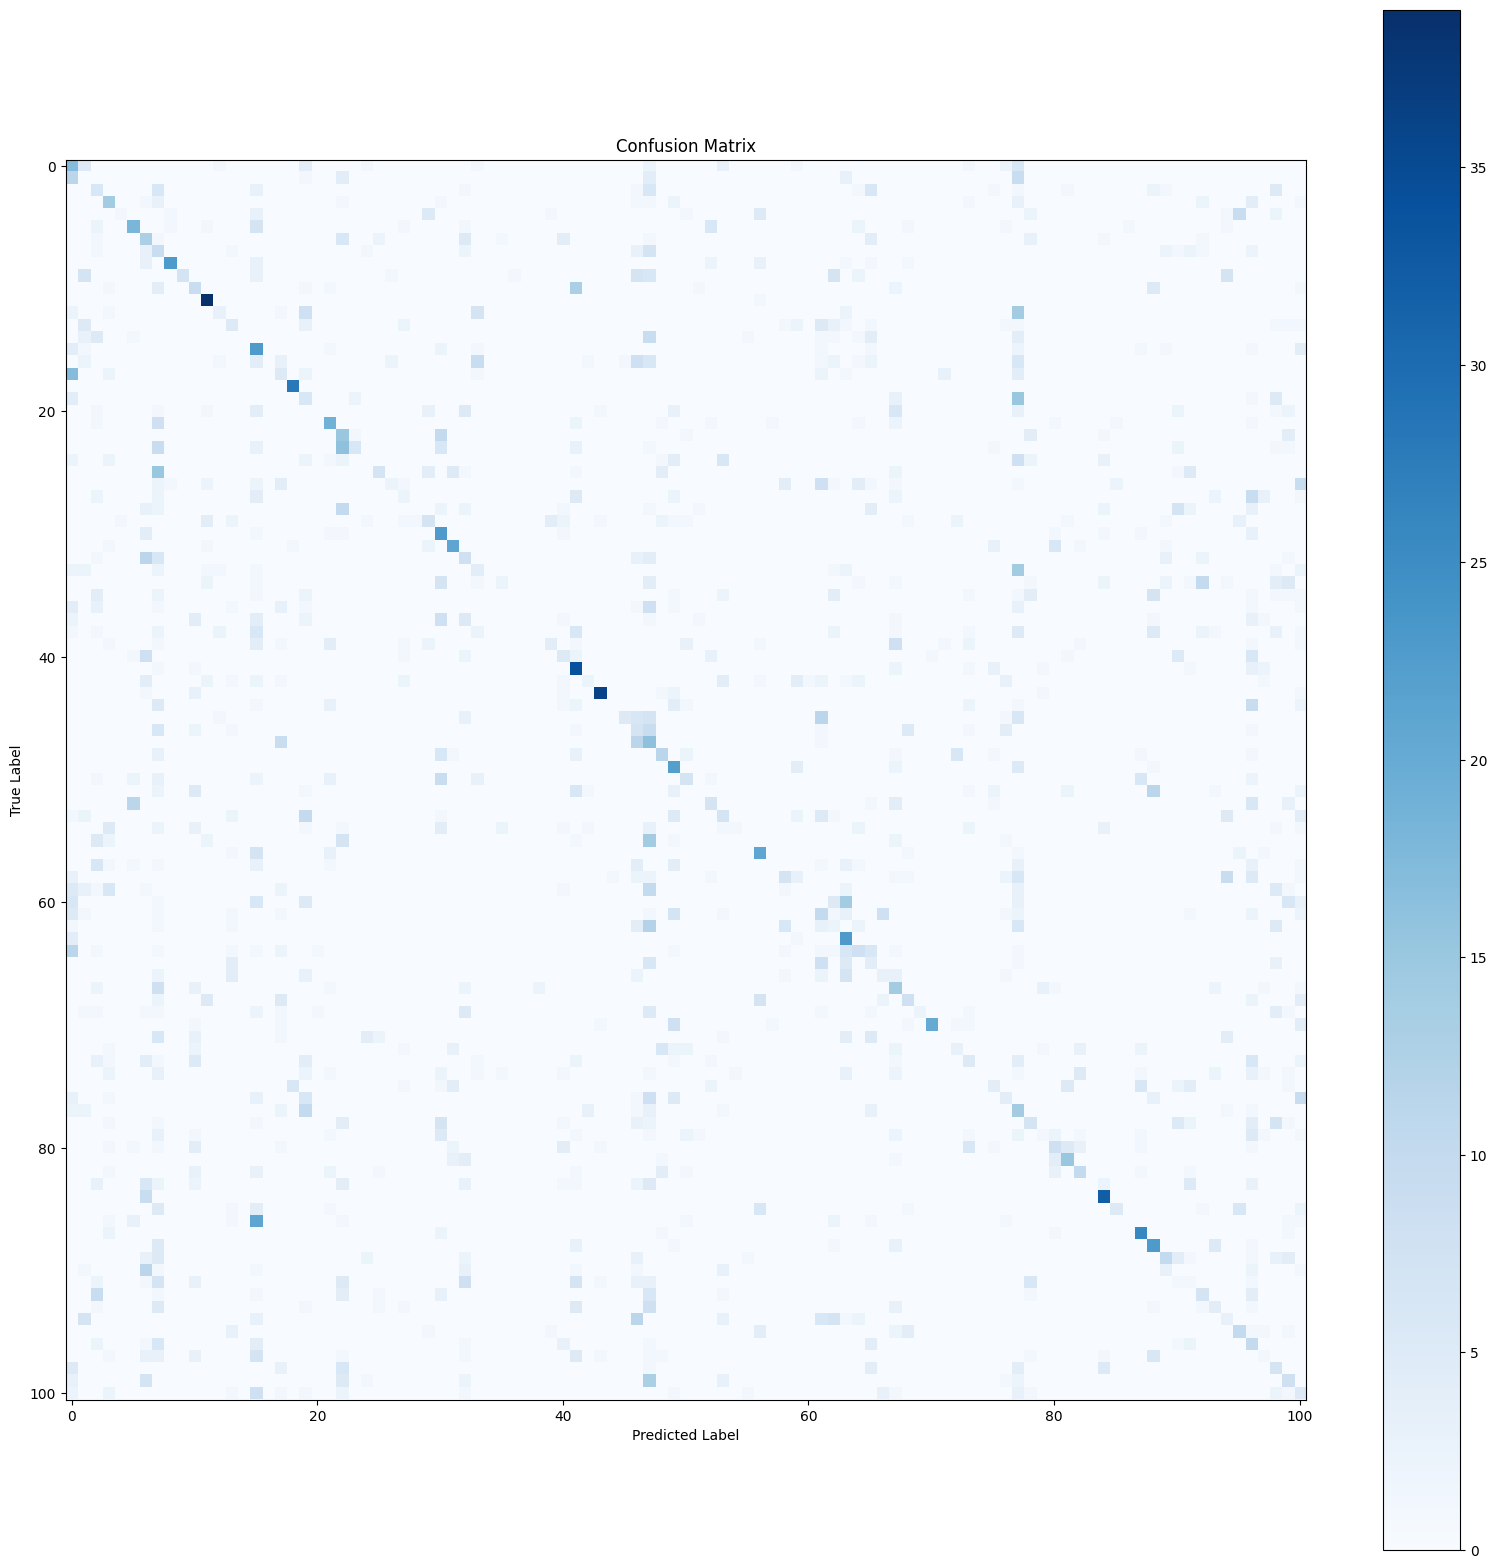

In [ ]:
plt.figure(figsize=(20, 20))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.colorbar()

plt.show()

Actual Class    : ApplyEyeMakeup
Predicted Class : ApplyLipstick


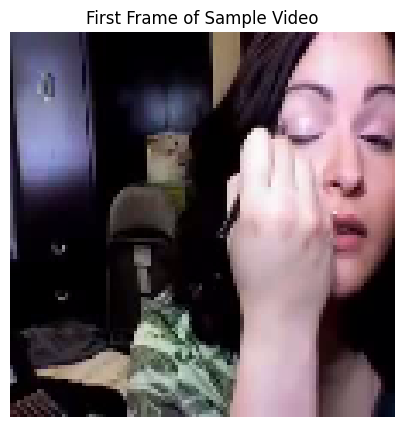

In [ ]:
sample_frames, sample_label = test_dataset[0]

sample_input = sample_frames.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(sample_input)

predicted_label = torch.argmax(output, dim=1).item()

print("Actual Class    :", classes[sample_label])
print("Predicted Class :", classes[predicted_label])

plt.figure(figsize=(5,5))
plt.imshow(sample_frames.permute(1,2,3,0)[0])
plt.title("First Frame of Sample Video")
plt.axis("off")
plt.show()

Sample Index : 6
Actual Class : ApplyEyeMakeup
Predicted Class : ApplyEyeMakeup


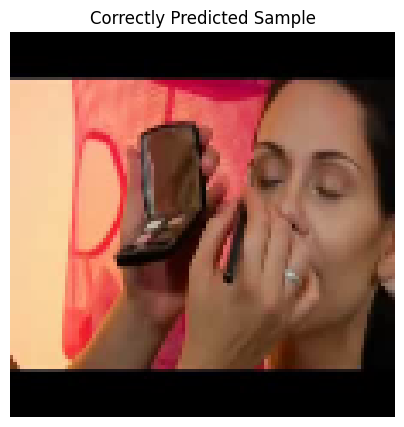

In [ ]:
model.eval()

found = False

with torch.no_grad():

    for i in range(len(test_dataset)):

        frames, true_label = test_dataset[i]

        input_video = frames.unsqueeze(0).to(device)

        output = model(input_video)

        predicted_label = torch.argmax(output, dim=1).item()

        if predicted_label == true_label:

            print("Sample Index :", i)
            print("Actual Class :", classes[true_label])
            print("Predicted Class :", classes[predicted_label])

            plt.figure(figsize=(5,5))
            plt.imshow(frames.permute(1,2,3,0)[0])
            plt.title("Correctly Predicted Sample")
            plt.axis("off")
            plt.show()

            found = True
            break

if not found:
    print("No correctly predicted sample found.")